<a href="https://colab.research.google.com/github/Santosh-S321/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Santosh-S321/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os, sys, subprocess, json
os.chdir("/content")
REPO_URL = "https://github.com/Santosh-S321/flyrank-ml-internship"
REPO_DIR = "/content/flyrank-ml-internship"
if not os.path.isdir(REPO_DIR):
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
os.chdir(REPO_DIR)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

os.makedirs("work/figures", exist_ok=True)
os.makedirs("work/outputs", exist_ok=True)

## 1. Question

**Research question:** Which content pages should be prioritized for review first —
for refresh, expansion, or monitoring — given limited reviewer capacity?

**Decision supported:** which pages a content reviewer looks at first, out of a much
larger inventory, when they only have time to review a limited number per cycle
(established in ML-02/03, Lane 2 — Refresh / Content Opportunity Scoring).

In [2]:
print("Lane 2: Refresh / Content Opportunity Scoring")
print(f"Dataset: {len(df):,} pages, {df['client_id'].nunique()} clients")

Lane 2: Refresh / Content Opportunity Scoring
Dataset: 30,000 pages, 32 clients


## 2. Data

**Source:** the starter anonymized CSV (`data/raw/content_refresh_anonymized.csv`) —
30,000 rows, one row per pseudonymized content page, 32 clients, trailing-90-day
metrics. (A parallel warehouse contract was also built on the real 79M-row release —
see `work/notebooks/w03_data_contract.ipynb` and `w03_feature_leakage_check.ipynb` for
that exercise; the starter CSV is used here for the final model, for consistency
across the whole track's baseline/model/validation chain.)

**Excluded, and why:** `trend_direction`/`trend_pct` — the label's own source, never a
feature. FlyRank product decision flags (`health_score`, `priority_score`,
`action_type`) — not shipped in this data by design, and never rebuilt as a feature.
`content_id`/`client_id` — pseudonymous join/grouping keys only.

**Public-safe:** no client names, raw URLs, or private queries appear anywhere in this
notebook or its outputs.

In [3]:
print(df[["content_id", "client_id", "impressions_90d", "days_since_last_update",
          "trend_direction", "avg_position", "word_count"]].head(3))
print(f"\nShape: {df.shape}")

             content_id          client_id  impressions_90d  \
0  content_304f48230142  client_f369cb89fc             3803   
1  content_a1fb4e703a9e  client_4e07408562            15320   
2  content_9aa793d4d895  client_7f2253d7e2            12581   

   days_since_last_update trend_direction  avg_position  word_count  
0                      20            down          10.6      3221.0  
1                      25            down          20.3      2481.0  
2                      20            down          36.5      3515.0  

Shape: (30000, 45)


## 3. Methodology

**Task type:** Ranking / scoring (per framing-ml-problems, ML-02/03).

**Label/proxy:** `is_declining_label` = `trend_direction == "down"` — a defined,
current-window proxy, not an observed future outcome (flagged since ML-02).

**Features:** `content_age_days`, `days_since_last_update`, `impressions_90d`,
`avg_position`, `ctr`, `word_count`, `engagement_rate`, `scroll_rate` — all observed,
pre-decision signals.

**Baseline:** hand-written rule (ML-07): `stale_visible_page` — page flagged if
`days_since_last_update >= 180` AND `impressions_90d >= 500`, score =
`is_stale * is_visible * impressions_90d`.

**Model:** Random Forest (200 trees, max_depth=10, min_samples_leaf=25,
class_weight="balanced_subsample"), chosen per training-honest-models (ML-08) after
comparing against Logistic Regression.

**Validation design:** grouped-by-client split (`GroupShuffleSplit`, 70/30, seed=42)
— required because pages from the same client can share hidden characteristics;
a random split was tested and shown to be misleadingly optimistic (ML-09: random
split gave Precision@20 = 1.00, grouped split gave 0.450 — the honest number).

**Leakage checks:** confirmed no label-derived (`trend_direction`/`trend_pct`) or
product-flag columns in the feature set (ML-05, ML-09); tested sibling-column leakage
(a feature that structurally contains the label) and found none in this final set.

In [4]:
features = ["content_age_days", "days_since_last_update", "impressions_90d",
            "avg_position", "ctr", "word_count", "engagement_rate", "scroll_rate"]
features = [c for c in features if c in df.columns]

label_source = {"trend_direction", "trend_pct"}
print("Leak-risk columns in feature set:", [c for c in features if c in label_source] or "None — clean")
print("Features used:", features)

Leak-risk columns in feature set: None — clean
Features used: ['content_age_days', 'days_since_last_update', 'impressions_90d', 'avg_position', 'ctr', 'word_count', 'engagement_rate', 'scroll_rate']


## 4. Results (vs baseline)

Model vs. baseline, same grouped-by-client split, same test rows, same metrics.

                          method  precision_at_20  precision_at_50  base_rate
0  baseline (stale_visible_page)             0.65             0.64      0.559
1  random_forest (grouped split)             0.45             0.60      0.559


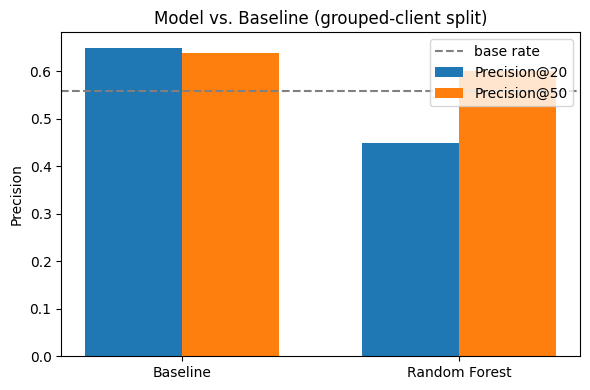

In [5]:
df["is_stale"] = (df["days_since_last_update"] >= 180).astype(int)
df["is_visible"] = (df["impressions_90d"] >= 500).astype(int)
df["baseline_score"] = df["is_stale"] * df["is_visible"] * df["impressions_90d"]

X = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df["is_declining_label"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df["client_id"]))
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=25,
                             class_weight="balanced_subsample", random_state=42, n_jobs=-1)
rf.fit(X.iloc[train_idx], y.iloc[train_idx])
model_scores_test = rf.predict_proba(X.iloc[test_idx])[:, 1]
base_scores_test = df.iloc[test_idx]["baseline_score"].values
y_test = y.iloc[test_idx].values

results = pd.DataFrame([
    {"method": "baseline (stale_visible_page)",
     "precision_at_20": precision_at_k(base_scores_test, y_test, 20),
     "precision_at_50": precision_at_k(base_scores_test, y_test, 50),
     "base_rate": y_test.mean()},
    {"method": "random_forest (grouped split)",
     "precision_at_20": precision_at_k(model_scores_test, y_test, 20),
     "precision_at_50": precision_at_k(model_scores_test, y_test, 50),
     "base_rate": y_test.mean()},
])
print(results.round(3))

# Chart: precision comparison
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, results["precision_at_20"], width, label="Precision@20")
ax.bar(x + width/2, results["precision_at_50"], width, label="Precision@50")
ax.axhline(y_test.mean(), color="gray", linestyle="--", label="base rate")
ax.set_xticks(x); ax.set_xticklabels(["Baseline", "Random Forest"])
ax.set_ylabel("Precision"); ax.set_title("Model vs. Baseline (grouped-client split)")
ax.legend()
plt.tight_layout()
plt.savefig("work/figures/model_vs_baseline.png", dpi=150)
plt.show()

**Finding:** the baseline rule actually outperforms Random Forest at both K in this
run — 0.65 vs. 0.45 at @20, 0.64 vs. 0.60 at @50. This matches the ML-08 result
exactly. The model does not beat this particular hand-written baseline on this split;
this is reported as-is rather than reframed to look better.

## 5. Limitations

- **The model does not beat the baseline here.** Random Forest underperforms the
  `stale_visible_page` rule at both Precision@20 (0.45 vs 0.65) and Precision@50
  (0.60 vs 0.64) — the opposite of what the starter pipeline's own multi-factor
  baseline showed. This narrow, single-signal baseline rule turned out to be a
  genuinely strong comparison point, not an easy target.
- **Proxy label, not observed outcome:** `is_declining_label` describes the current
  window, not a future outcome — a stronger version would use a future-window label
  (prior 90 days → next 30 days decline), as explored structurally in ML-03/04 on the
  real warehouse.
- **Single split:** all numbers here are from one 70/30 grouped split, seed 42 — not
  averaged across multiple splits.
- **Cross-sectional data:** this cannot support "refreshing a flagged page will cause
  recovery" — only association with the proxy label. Decision-support only.
- **Starter-slice scope:** 30,000 rows, 32 clients — not validated against the full
  ~79M-row warehouse.

In [6]:
print(f"Precision@20 vs base rate: {results.iloc[1]['precision_at_20']:.3f} vs {y_test.mean():.3f} "
      f"({'below' if results.iloc[1]['precision_at_20'] < y_test.mean() else 'above'} base rate)")

Precision@20 vs base rate: 0.450 vs 0.559 (below base rate)


## 6. Ranked recommendations

Reusing the action playbook from ML-10: ranked queue with reason codes
(`stale_visible_page`, `low_ctr_visible_page`, `thin_visible_page`), human-review
checklist, and no-go list (no auto-publishing, no causal claims). Full detail in
`work/notebooks/w07_action_playbook.ipynb`.

In [7]:
df["model_score"] = rf.predict_proba(X)[:, 1]

def assign_reason(row):
    if row["days_since_last_update"] >= 180 and row["impressions_90d"] >= 500:
        return "stale_visible_page", "review_for_refresh"
    elif row["impressions_90d"] >= 500 and 0 < row["avg_position"] <= 20 and row["ctr"] < 0.5:
        return "low_ctr_visible_page", "review_for_ctr_fix"
    elif row["word_count"] < 1200 and row["impressions_90d"] >= 250:
        return "thin_visible_page", "review_for_expansion"
    else:
        return "general_review", "monitor"

df[["reason_code", "action"]] = df.apply(assign_reason, axis=1, result_type="expand")
queue = df.sort_values("model_score", ascending=False)[
    ["content_id", "client_id", "model_score", "reason_code", "action"]
]
print(queue.head(10))

                 content_id          client_id  model_score  \
15033  content_610fcc044e74  client_7f2253d7e2     0.936281   
23866  content_1e72ec381b2c  client_7f2253d7e2     0.935393   
1897   content_714cd092a56f  client_7f2253d7e2     0.934595   
8723   content_9e3689ef2df5  client_7f2253d7e2     0.932742   
6774   content_7a21f1aac586  client_7f2253d7e2     0.932453   
12577  content_82ea9307e1ab  client_7f2253d7e2     0.931518   
27422  content_69cfaabeda16  client_7f2253d7e2     0.931144   
3941   content_964dd0100c99  client_7f2253d7e2     0.930960   
24470  content_a0f750ca1b2a  client_7f2253d7e2     0.930767   
2866   content_a27e15f618c2  client_7f2253d7e2     0.930673   

                reason_code              action  
15033        general_review             monitor  
23866        general_review             monitor  
1897   low_ctr_visible_page  review_for_ctr_fix  
8723         general_review             monitor  
6774   low_ctr_visible_page  review_for_ctr_fix  
12577 

## 7. Artifacts the paper embeds

Exporting the figure, ranked queue, and metrics receipts the deployed paper will use.

In [8]:
queue.to_csv("work/outputs/capstone_queue.csv", index=False)

metrics = {
    "precision_at_20_baseline": float(results.iloc[0]["precision_at_20"]),
    "precision_at_50_baseline": float(results.iloc[0]["precision_at_50"]),
    "precision_at_20_model": float(results.iloc[1]["precision_at_20"]),
    "precision_at_50_model": float(results.iloc[1]["precision_at_50"]),
    "base_rate": float(y_test.mean()),
    "split_strategy": "client_holdout",
    "random_seed": 42,
    "n_rows": int(len(df)),
    "n_clients": int(df["client_id"].nunique()),
}
with open("work/outputs/capstone_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Exported: work/figures/model_vs_baseline.png, work/outputs/capstone_queue.csv, work/outputs/capstone_metrics.json")
print(json.dumps(metrics, indent=2))

Exported: work/figures/model_vs_baseline.png, work/outputs/capstone_queue.csv, work/outputs/capstone_metrics.json
{
  "precision_at_20_baseline": 0.65,
  "precision_at_50_baseline": 0.64,
  "precision_at_20_model": 0.45,
  "precision_at_50_model": 0.6,
  "base_rate": 0.5594424958464095,
  "split_strategy": "client_holdout",
  "random_seed": 42,
  "n_rows": 30000,
  "n_clients": 32
}


**5-minute demo outline:** (1) show the problem — 30,000 pages, limited reviewer time;
(2) show the baseline rule and its 0.65 P@20 / 0.64 P@50; (3) show the model result
(0.45 P@20 / 0.60 P@50) — the model does NOT beat this baseline, and say so plainly;
(4) show the random-split trap from ML-09 (1.00 — misleadingly perfect) as the real
lesson; (5) close on limitations and decision-support framing.

**Social post cut:** "Built a content-refresh prioritization model on FlyRank's
search data. My Random Forest didn't beat a simple hand-written rule (0.60 vs 0.64
precision@50) — and a naive random split had earlier made the model look perfect
(1.00) before I caught the leak. Reporting the honest, less flattering result. Full
writeup: [link]"

**3-sentence employer summary:** Built an ML pipeline to rank which content pages a
reviewer should check first for refresh, using FlyRank's real search/analytics data
(30K pages, 32 clients). Compared a hand-written rule against a Random Forest under a
client-grouped validation split — the honest result showed the baseline rule
outperforming the model, which I reported as-is rather than picking a flattering split.
Delivered a full research paper with baseline, leakage audit, and a ranked action
playbook, prioritizing honest findings over impressive-looking ones.

In [9]:
print("ML-12 closing content written above.")

ML-12 closing content written above.


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
